# Análisis exploratorio y Modelo Predictivo: Online Retail II

**Objetivo**: Construir un modelo para predecir la probabilidad de que un cliente repita compra en la tienda.

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost openpyxl

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import xgboost as xgb

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

In [23]:
# Carga de datos 
DATA_PATH = r'online_retail_II.xlsx'
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


## 2. Primera inspección

In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


## 3. Calidad de datos (Limpieza)

In [ ]:
print(f"Filas originales: {len(df):,}")


# 0. Estandarizar nombres de columnas según el diccionario
df = df.rename(columns={
    'Customer ID': 'CustomerID',
    'Invoice': 'InvoiceNo',
    'Price': 'UnitPrice'
})

# 1. Eliminar duplicados
print(f"Duplicados antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicados después: {df.duplicated().sum()}")

# 2. Valores nulos
print("\nNulos por columna:")
print(df.isnull().sum())
df = df.dropna(subset=['CustomerID'])

# 3. Eliminar cancelaciones y validar InvoiceNo (6 dígitos)
df = df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C')]
df['InvoiceNo'] = df['InvoiceNo'].astype(str).str.replace(r'\D', '', regex=True)
df = df[df['InvoiceNo'].str.len() == 6]

# 4. Validar StockCode (5 dígitos)
df['StockCode'] = df['StockCode'].astype(str).str.replace(r'\D', '', regex=True)
df = df[df['StockCode'].str.len() == 5]

# 5. Validar CustomerID (5 dígitos)
df['CustomerID'] = df['CustomerID'].astype(str).str.split('.').str[0] # Corrige formato float
df['CustomerID'] = df['CustomerID'].str.replace(r'\D', '', regex=True)
df = df[df['CustomerID'].str.len() == 5]

# 6. Cantidad y precio positivos
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'], errors='coerce')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 7. Calcular revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"\nFilas finales tras limpieza: {len(df):,}")

Filas originales: 1,067,371
Duplicados antes: 34335
Duplicados después: 0

Nulos por columna:
InvoiceNo           0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     235151
Country             0
dtype: int64

Filas finales tras limpieza: 776,577


## 4. Estadísticas descriptivas y Visualizaciones

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue
count,776577.000000,776577,776577.000000,776577.000000
mean,13.519243,2011-01-03 00:44:11.290393,2.934561,21.979234
min,1.000000,2009-12-01 07:45:00,0.030000,0.060000
25%,2.000000,2010-07-02 14:15:00,1.250000,4.950000
50%,6.000000,2010-12-02 13:49:00,1.950000,12.450000
75%,12.000000,2011-08-01 13:31:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,649.500000,168469.600000
std,146.096695,NaN,4.293610,225.932983


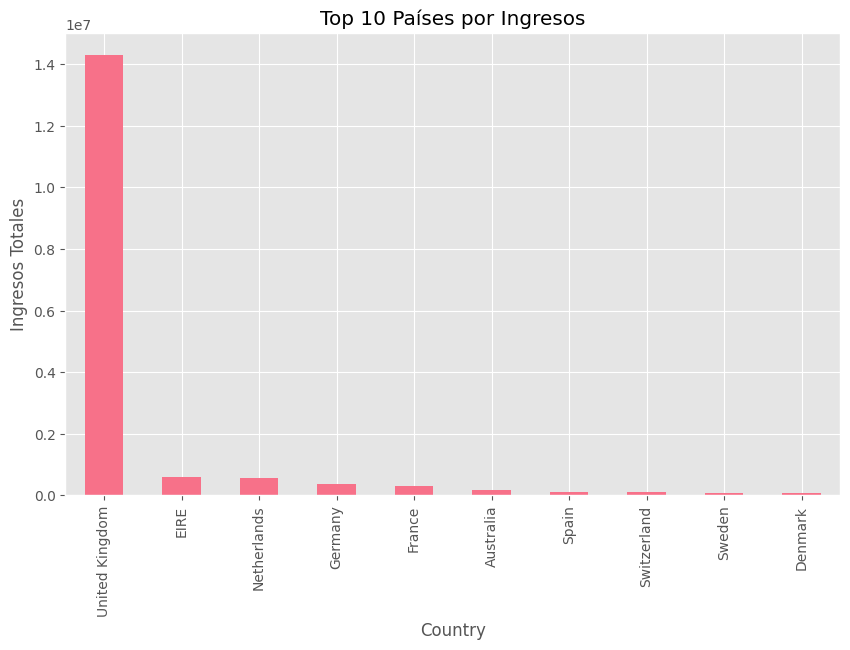

In [ ]:
# Top 10 Países por ingresos
plt.figure(figsize=(10,6))
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Países por Ingresos')
plt.ylabel('Ingresos Totales')
plt.show()

## 5. Construcción de Variables (RFM) y Variable Objetivo

Estrategia de Modelado:
1. Definimos una fecha de corte (`cutoff_date`), por ejemplo, 6 meses antes de la fecha máxima del dataset.
2. Con los datos antes de la fecha de corte, generamos variables históricas por cliente (Recency, Frequency, Monetary).
3. Con los datos posteriores a la fecha de corte, vemos si el cliente compró (Target = 1) o no (Target = 0).

In [ ]:
# El dataset va de dic 2009 a dic 2011.
print("Fecha mínima:", df['InvoiceDate'].min())
print("Fecha máxima:", df['InvoiceDate'].max())

# Usaremos los últimos 6 meses para la variable objetivo
cutoff_date = df['InvoiceDate'].max() - pd.DateOffset(months=6)

# Dividir dataset histórico y futuro
df_features = df[df['InvoiceDate'] < cutoff_date]
df_target = df[df['InvoiceDate'] >= cutoff_date]

print(f"Fecha de corte: {cutoff_date}")

Fecha mínima: 2009-12-01 07:45:00
Fecha máxima: 2011-12-09 12:50:00
Fecha de corte: 2011-06-09 12:50:00


In [ ]:
# Generar características a nivel cliente (Modelo RFM)
rfm = df_features.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (cutoff_date - x.max()).days, # Recency: días desde última compra
    'InvoiceNo': 'nunique',                                # Frequency: nº de compras distintas
    'Revenue': 'sum'                                       # Monetary: gasto total acumulado
})

# Renombrar las columnas resultantes para mayor claridad en el modelo
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Mostrar las primeras filas para verificar que se generó correctamente
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346           142          3  77352.96
12347            63          4   2434.96
12348            65          4   1388.40
12349           224          2   2221.14
12350           126          1    294.40


## 6. Tratamiento de Outliers (en características RFM)

In [ ]:
# Eliminar outliers extremos en Monetary o Frequency usando percentiles
p99_monetary = rfm['Monetary'].quantile(0.99)
p99_freq = rfm['Frequency'].quantile(0.99)

print(f"Clientes antes de limpiar outliers: {len(rfm)}")
rfm = rfm[(rfm['Monetary'] <= p99_monetary) & (rfm['Frequency'] <= p99_freq)]
print(f"Clientes tras limpiar outliers: {len(rfm)}")

Clientes antes de limpiar outliers: 4942
Clientes tras limpiar outliers: 4872


## 7. Modelado

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Identificamos qué clientes compraron en los últimos 6 meses
clientes_recompra = df_target['CustomerID'].astype(str).unique()

# 2. Creamos la columna 'Target' en nuestra tabla rfm
rfm['Target'] = rfm.index.isin(clientes_recompra).astype(int)

print("Distribución del Target:")
print(rfm['Target'].value_counts())

# 3. Separar variables predictoras (X) y variable objetivo (y)
X = rfm.drop('Target', axis=1)
y = rfm['Target']

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamaño de X_train: {X_train.shape}")

Distribución del Target:
Target
1    2510
0    2362
Name: count, dtype: int64

Tamaño de X_train: (3897, 3)


In [ ]:

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: Regresión Logística (USANDO DATOS ESCALADOS)
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)
lr_pred_prob = lr.predict_proba(X_test_scaled)[:, 1]
print("AUC Regresión Logística:", roc_auc_score(y_test, lr_pred_prob))

# Modelo 2: Random Forest (USANDO DATOS ORIGINALES)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred_prob = rf.predict_proba(X_test)[:, 1]
print("AUC Random Forest:", roc_auc_score(y_test, rf_pred_prob))

# Modelo 3: XGBoost (USANDO DATOS ORIGINALES)
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
print("AUC XGBoost:", roc_auc_score(y_test, xgb_pred_prob))

AUC Regresión Logística: 0.7826958550575709
AUC Random Forest: 0.7461591267067038
AUC XGBoost: 0.7668248780775417


## 8. Optimización de hiperparámetros

In [ ]:
# Optimizaremos el modelo Random Forest como ejemplo
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rs = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_dist, n_iter=15, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_
print("Mejores hiperparámetros:", rs.best_params_)

best_pred_prob = best_model.predict_proba(X_test)[:, 1]
print("Mejor AUC Random Forest Tras Optimización:", roc_auc_score(y_test, best_pred_prob))

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5}
Mejor AUC Random Forest Tras Optimización: 0.7875369557709964


## 9. Resultados y Explicabilidad

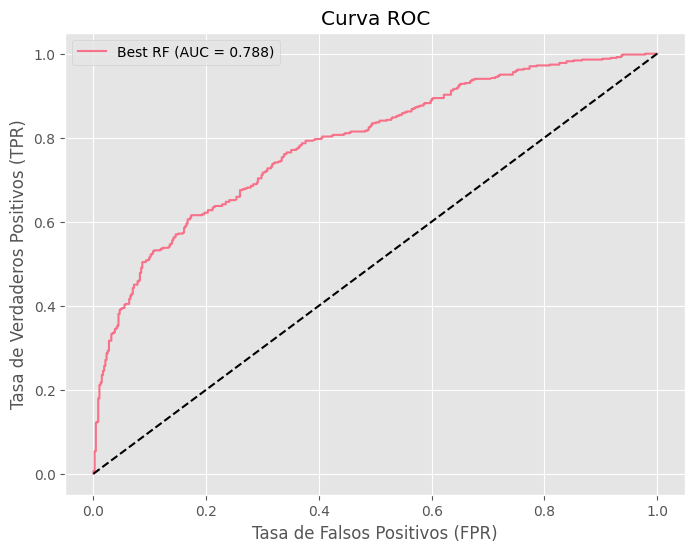

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, best_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Best RF (AUC = {roc_auc_score(y_test, best_pred_prob):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

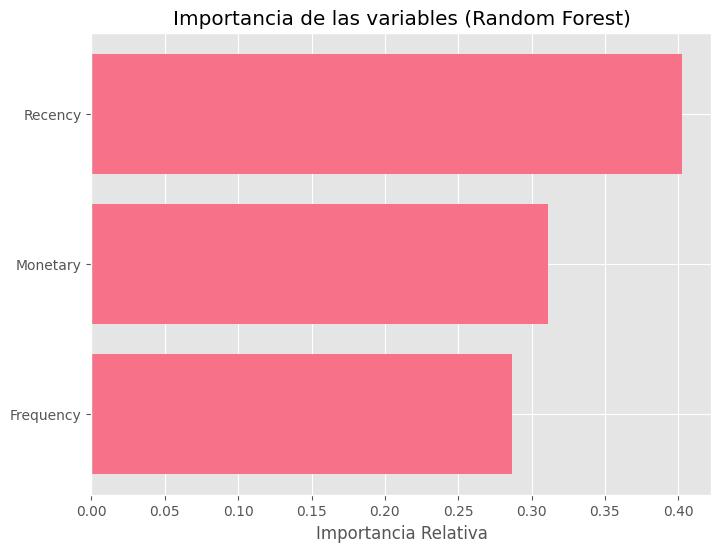

In [ ]:
# Importancia de variables
importances = best_model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.title('Importancia de las variables (Random Forest)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.show()